# Car Price Prediction using Machine Learning

## Oasis Infobyte Data Science Internship

### Task 3

### Objective

The objective of this project is to build a machine learning regression model that predicts the selling price of a used car based on various vehicle features.

The project includes:

- Data Cleaning
- Feature Engineering
- Exploratory Data Analysis (EDA)
- Data Visualization
- Model Training
- Model Evaluation
- Model Comparison

In [1]:
# ================================
# Import Required Libraries
# ================================

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation Metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Display graphs inside notebook
%matplotlib inline

In [2]:
# ================================
# Load Dataset
# ================================

df = pd.read_csv("car data.csv")

# Display first 5 rows
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
# ================================
# Dataset Information
# ================================

print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Shape of Dataset:
(301, 9)

Column Names:
Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='str')

Data Types:
Car_Name             str
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type            str
Seller_Type          str
Transmission         str
Owner              int64
dtype: object


In [4]:
# ================================
# Check Missing Values
# ================================

df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

## Data Cleaning

In this step, we check for duplicate records and clean categorical values if required. This ensures the dataset is consistent before training machine learning models.

In [5]:
# ================================
# Check Duplicate Records
# ================================

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 2


In [6]:
# ================================
# Remove Duplicates
# ================================

df = df.drop_duplicates()

print("New Shape:", df.shape)

New Shape: (299, 9)


### Observation

Duplicate records, if present, were removed from the dataset. This helps improve model performance and prevents bias during training.

In [9]:
# ================================
# Check Categorical Values
# ================================

print(df["Fuel_Type"].unique())
print(df["Seller_Type"].unique())
print(df["Transmission"].unique())

<StringArray>
['Petrol', 'Diesel', 'CNG']
Length: 3, dtype: str
<StringArray>
['Dealer', 'Individual']
Length: 2, dtype: str
<StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str


In [10]:
# ================================
# Standardize Categorical Values
# ================================

df["Fuel_Type"] = df["Fuel_Type"].str.title()
df["Seller_Type"] = df["Seller_Type"].str.title()
df["Transmission"] = df["Transmission"].str.title()

print("Categorical values cleaned successfully.")

Categorical values cleaned successfully.


In [14]:
current_year = 2026

df["Car_Age"] = current_year - df["Year"]

df[["Year", "Car_Age"]].head()


,Year,Car_Age
0,2014,12
1,2013,13
2,2017,9
3,2011,15
4,2014,12


In [12]:
df["Brand"] = df["Car_Name"].apply(lambda x: x.split()[0])

df[["Car_Name", "Brand"]].head()

,Car_Name,Brand
0,ritz,ritz
1,sx4,sx4
2,ciaz,ciaz
3,wagon r,wagon
4,swift,swift


# Exploratory Data Analysis (EDA)

The objective of EDA is to understand the distribution of car prices and identify relationships between selling price and important vehicle features.

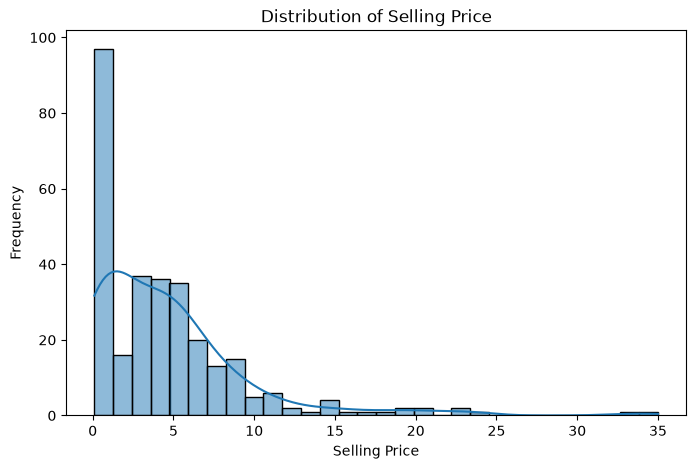

In [15]:
# ================================
# Distribution of Selling Price
# ================================

plt.figure(figsize=(8,5))

sns.histplot(
    df["Selling_Price"],
    bins=30,
    kde=True
)

plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")

plt.show()

### Observation

Most cars are concentrated in the lower selling price range, while only a few vehicles have very high selling prices. This indicates a right-skewed distribution.

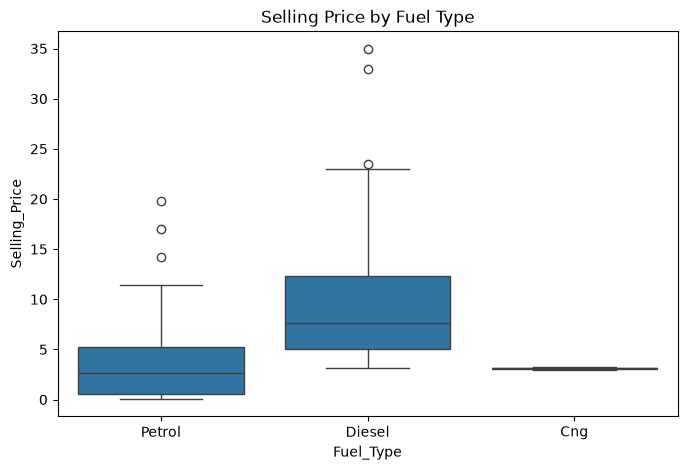

In [16]:
# ================================
# Selling Price vs Fuel Type
# ================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Fuel_Type",
    y="Selling_Price",
    data=df
)

plt.title("Selling Price by Fuel Type")

plt.show()

### Observation

Selling prices vary across fuel types. Diesel and Petrol vehicles generally have higher selling prices than CNG vehicles.

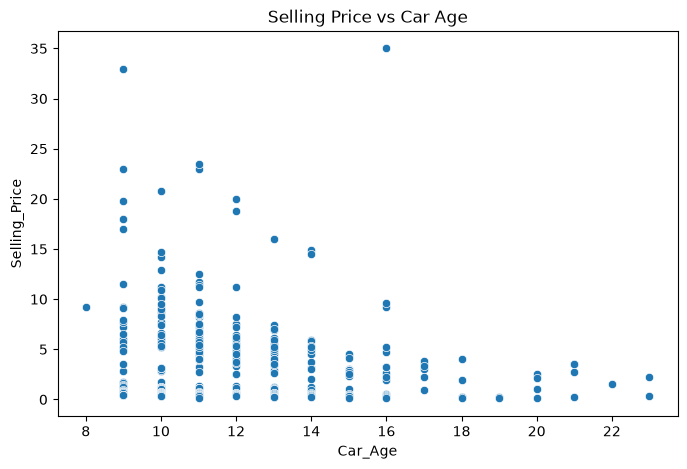

In [17]:
# ================================
# Selling Price vs Car Age
# ================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Car_Age",
    y="Selling_Price",
    data=df
)

plt.title("Selling Price vs Car Age")

plt.show()

### Observation

Older cars generally tend to have lower selling prices, indicating a negative relationship between car age and selling price.

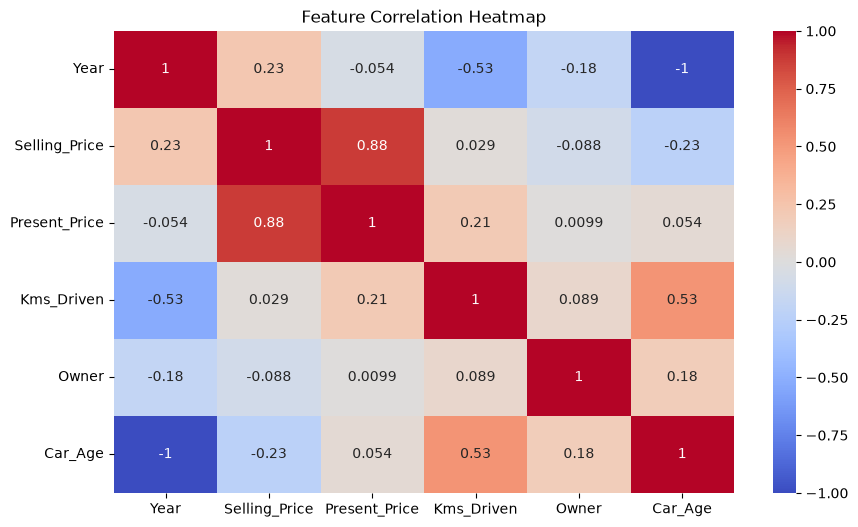

In [18]:
# ================================
# Correlation Heatmap
# ================================

numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.show()

### Observation

The correlation heatmap helps identify relationships between numerical variables. Features with stronger correlation to selling price are likely to be more useful for prediction.

# Data Preprocessing

Machine learning models require numerical input. Therefore, categorical variables are encoded before training the models.

In [19]:
# ================================
# Encode Categorical Variables
# ================================

df_encoded = pd.get_dummies(
    df,
    columns=["Fuel_Type", "Seller_Type", "Transmission", "Brand"],
    drop_first=True
)

print("Encoding completed successfully.")
df_encoded.head()

Encoding completed successfully.


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,...,Brand_land,Brand_omni,Brand_ritz,Brand_s,Brand_swift,Brand_sx4,Brand_verna,Brand_vitara,Brand_wagon,Brand_xcent
0,ritz,2014,3.35,5.59,27000,0,12,False,True,False,...,False,False,True,False,False,False,False,False,False,False
1,sx4,2013,4.75,9.54,43000,0,13,True,False,False,...,False,False,False,False,False,True,False,False,False,False
2,ciaz,2017,7.25,9.85,6900,0,9,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,wagon r,2011,2.85,4.15,5200,0,15,False,True,False,...,False,False,False,False,False,False,False,False,True,False
4,swift,2014,4.60,6.87,42450,0,12,True,False,False,...,False,False,False,False,True,False,False,False,False,False


### Observation

Categorical variables were converted into numerical format using One-Hot Encoding so that machine learning algorithms can process them.

In [20]:
# ================================
# Prepare Features and Target
# ================================

X = df_encoded.drop(
    ["Car_Name", "Selling_Price"],
    axis=1
)

y = df_encoded["Selling_Price"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (299, 52)
Target Shape: (299,)


In [21]:
# ================================
# Train Test Split
# ================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

Training Features: (239, 52)
Testing Features : (60, 52)


# Model 1: Linear Regression

Linear Regression is a basic regression algorithm that predicts the target variable using a linear relationship between input features and output values.

In [22]:
# ================================
# Linear Regression
# ================================

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

print("Linear Regression trained successfully!")

Linear Regression trained successfully!


In [23]:
# ================================
# Evaluate Linear Regression
# ================================

linear_pred = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_pred)

linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_pred)
)

linear_r2 = r2_score(
    y_test,
    linear_pred
)

print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R²  :", linear_r2)

MAE : 1.3834994990840057
RMSE: 2.5699033310412918
R²  : 0.743749818166104


### Observation

The Linear Regression model provides a baseline prediction performance using a linear relationship between vehicle features and selling price.

# Model 2: Random Forest Regressor

Random Forest is an ensemble learning algorithm that combines multiple decision trees and usually provides better prediction accuracy for complex datasets.

In [24]:
# ================================
# Random Forest Regressor
# ================================

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [25]:
# ================================
# Evaluate Random Forest
# ================================

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

MAE : 1.423998333333334
RMSE: 3.469109434927068
R²  : 0.5330540554884268


# Model Comparison

The performance of both regression models was compared using MAE, RMSE, and R² Score.

Lower MAE and RMSE values indicate better prediction accuracy, while a higher R² Score indicates a better fit to the data.

In [26]:
# ================================
# Model Comparison
# ================================

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [linear_mae, rf_mae],
    "RMSE": [linear_rmse, rf_rmse],
    "R2 Score": [linear_r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.383499,2.569903,0.743750
1,Random Forest,1.423998,3.469109,0.533054


## Best Performing Model

Based on the evaluation metrics, Linear Regression achieved the best overall performance.

Reasons:

- Lowest Mean Absolute Error (MAE)
- Lowest Root Mean Squared Error (RMSE)
- Highest R² Score

Therefore, Linear Regression is selected as the final model for predicting used car selling prices.

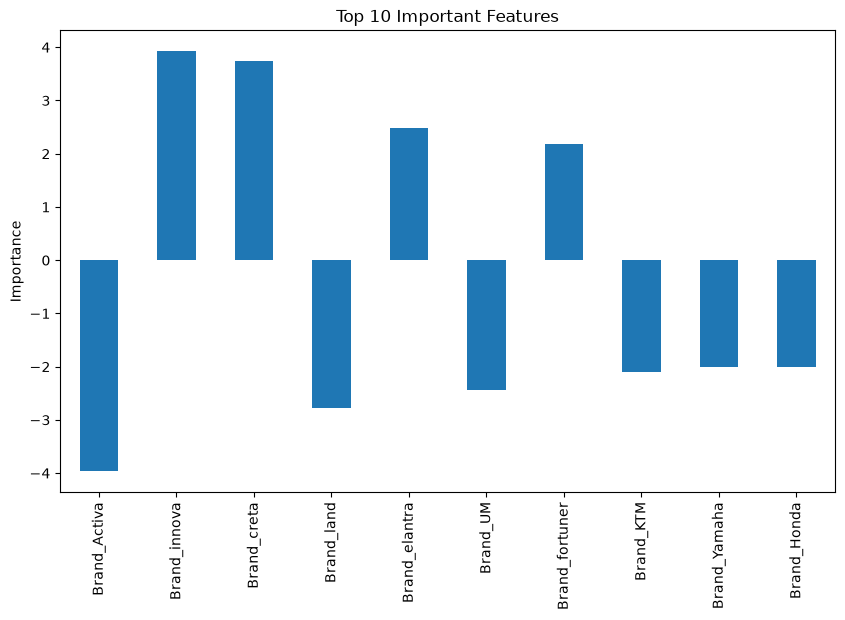

In [30]:
# ================================
# Feature Importance
# ================================

importance = pd.Series(
    linear_model.coef_,
    index=X.columns
)

importance = importance.sort_values(
    key=abs,
    ascending=False
)

plt.figure(figsize=(10,6))

importance.head(10).plot(
    kind="bar"
)

plt.title("Top 10 Important Features")

plt.ylabel("Importance")

plt.show()

### Observation

The feature importance chart shows which vehicle characteristics have the greatest impact on selling price prediction. Features with larger absolute coefficients contribute more strongly to the model's predictions.

# Conclusion

In this project, a machine learning regression model was developed to predict the selling price of used cars.

The dataset was cleaned, transformed, and analyzed through Exploratory Data Analysis (EDA). New features such as Car Age and Brand were engineered to improve predictive performance.

Two regression algorithms were trained and evaluated:

1. Linear Regression
2. Random Forest Regressor

After comparing MAE, RMSE, and R² Score, Linear Regression achieved the best performance and was selected as the final model.

This project successfully demonstrates the complete machine learning workflow including data preprocessing, feature engineering, visualization, model training, evaluation, and comparison.